### AI Startup Success Predictor & Venture Analytics


### 1. Environment Configuration & Library Imports


In [1]:
import os
import sys
import json
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ML & Preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report
)

# Style & Plot Settings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.titlesize'] = 16

# Custom harmonious color palette
BRAND_COLORS = ["#2563EB", "#10B981", "#F59E0B", "#EF4444", "#8B5CF6", "#06B6D4"]
sns.set_palette(BRAND_COLORS)

print("Environment configured successfully. Ready for analysis.")


Environment configured successfully. Ready for analysis.


### 2. Data Ingestion & Initial Integrity Profiling


In [2]:
# Path resolution to accommodate multiple repository execution roots
potential_paths = [
    '../datasets/startup_data.csv',
    'datasets/startup_data.csv',
    '../Data/big_startup_secsees_dataset.csv',
    'Data/big_startup_secsees_dataset.csv',
    'big_startup_secsees_dataset.csv'
]

dataset_path = None
for p in potential_paths:
    if os.path.exists(p):
        dataset_path = p
        break

if not dataset_path:
    raise FileNotFoundError("Startup dataset not found in expected locations.")

print(f"Loading startup dataset from: {dataset_path}")
raw_df = pd.read_csv(dataset_path)

print(f"Total Records: {raw_df.shape[0]:,}")
print(f"Total Columns: {raw_df.shape[1]}")
raw_df.head()


Loading startup dataset from: datasets/startup_data.csv


Total Records: 66,368
Total Columns: 14


,permalink,name,homepage_url,category_list,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,founded_at,first_funding_at,last_funding_at
0,/organization/-fame,#fame,http://livfame.com,Media,10000000,operating,IND,16,Mumbai,Mumbai,1,NaN,2015-01-05,2015-01-05
1,/organization/-qounter,:Qounter,http://www.qounter.com,Application Platforms|Real Time|Social Network...,700000,operating,USA,DE,DE - Other,Delaware City,2,2014-09-04,2014-03-01,2014-10-14
2,/organization/-the-one-of-them-inc-,"(THE) ONE of THEM,Inc.",http://oneofthem.jp,Apps|Games|Mobile,3406878,operating,NaN,NaN,NaN,NaN,1,NaN,2014-01-30,2014-01-30
3,/organization/0-6-com,0-6.com,http://www.0-6.com,Curated Web,2000000,operating,CHN,22,Beijing,Beijing,1,2007-01-01,2008-03-19,2008-03-19
4,/organization/004-technologies,004 Technologies,http://004gmbh.de/en/004-interact,Software,-,operating,USA,IL,"Springfield, Illinois",Champaign,1,2010-01-01,2014-07-24,2014-07-24


In [3]:
# Dataset schema and column summary
raw_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66368 entries, 0 to 66367
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   permalink          66368 non-null  object
 1   name               66367 non-null  object
 2   homepage_url       61310 non-null  object
 3   category_list      63220 non-null  object
 4   funding_total_usd  66368 non-null  object
 5   status             66368 non-null  object
 6   country_code       59410 non-null  object
 7   state_code         57821 non-null  object
 8   region             58338 non-null  object
 9   city               58340 non-null  object
 10  funding_rounds     66368 non-null  int64 
 11  founded_at         51147 non-null  object
 12  first_funding_at   66344 non-null  object
 13  last_funding_at    66368 non-null  object
dtypes: int64(1), object(13)
memory usage: 7.1+ MB


### Visualization 1: Missing Data Distribution Audit


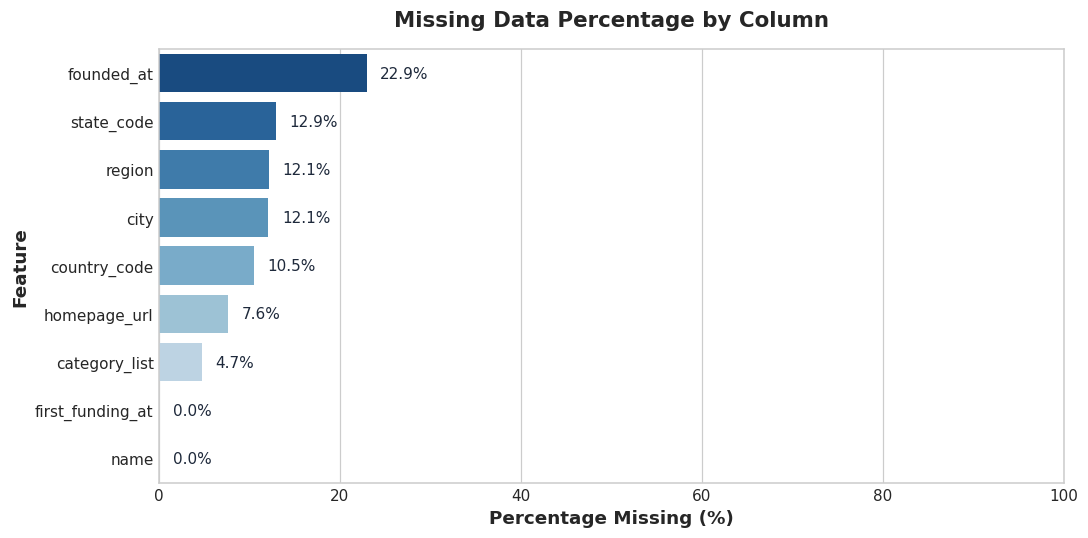

In [4]:
missing_series = (raw_df.isnull().sum() / len(raw_df) * 100).sort_values(ascending=False)
missing_df = pd.DataFrame({'Feature': missing_series.index, 'Missing_Percent': missing_series.values})
missing_df = missing_df[missing_df['Missing_Percent'] > 0]

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=missing_df, 
    x='Missing_Percent', 
    y='Feature', 
    palette='Blues_r', 
    edgecolor='none'
)
plt.title('Missing Data Percentage by Column', pad=15)
plt.xlabel('Percentage Missing (%)')
plt.ylabel('Feature')
plt.xlim(0, 100)

for p in ax.patches:
    val = p.get_width()
    ax.annotate(f'{val:.1f}%', 
                (val + 1.5, p.get_y() + p.get_height() / 2),
                ha='left', va='center', fontsize=10, fontweight='medium', color='#1e293b')

plt.tight_layout()
plt.show()


### 3. Target Formulation & Class Distribution Analysis


### Visualization 2: Status Breakdown & Binary Target Distribution


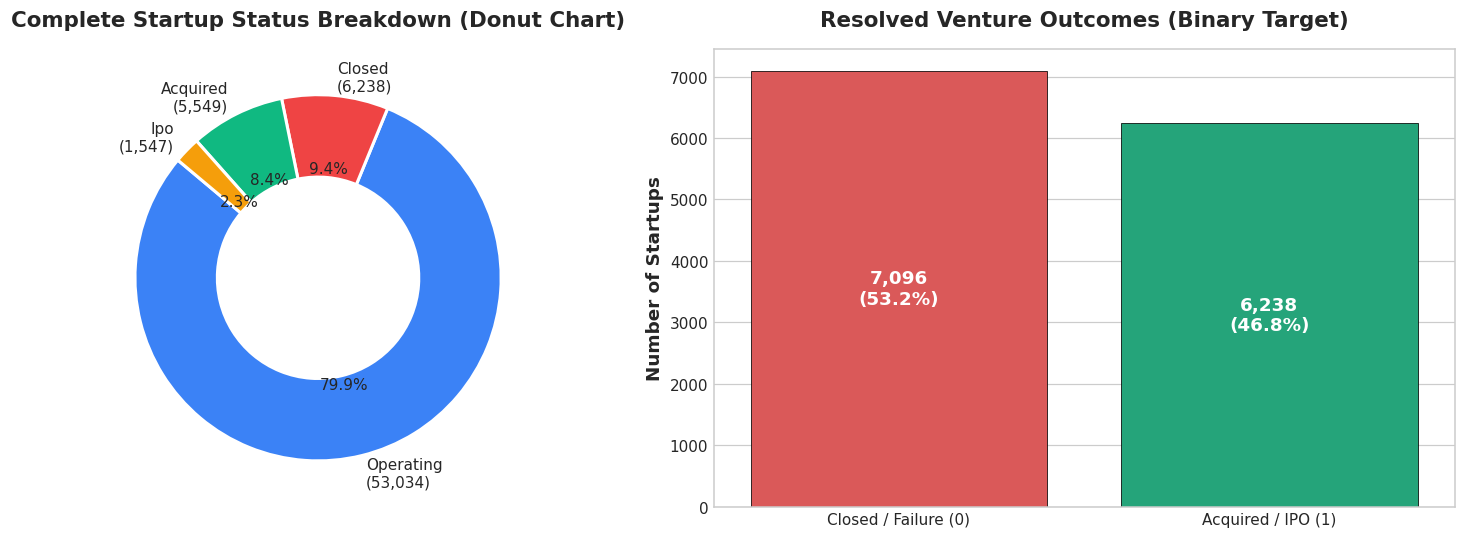

Total Resolved Startups for Classification: 13,334
Positive Class (Exit): 7,096 (53.2%)
Negative Class (Closed): 6,238 (46.8%)


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: All statuses breakdown
status_counts = raw_df['status'].value_counts(dropna=False)
status_colors = ['#3B82F6', '#EF4444', '#10B981', '#F59E0B']

axes[0].pie(
    status_counts.values, 
    labels=[f"{k.capitalize()}\n({v:,})" for k, v in zip(status_counts.index, status_counts.values)],
    autopct='%1.1f%%', 
    startangle=140, 
    colors=status_colors,
    wedgeprops=dict(width=0.45, edgecolor='white', linewidth=2)
)
axes[0].set_title('Complete Startup Status Breakdown (Donut Chart)', pad=15)

# Subplot 2: Resolved classification target distribution
resolved_mask = raw_df['status'].isin(['acquired', 'ipo', 'closed'])
resolved_df = raw_df[resolved_mask].copy()
resolved_df['target'] = resolved_df['status'].apply(lambda s: 1 if s in ['acquired', 'ipo'] else 0)

target_counts = resolved_df['target'].value_counts()
target_labels = ['Closed / Failure (0)', 'Acquired / IPO (1)']

sns.barplot(
    x=target_labels, 
    y=target_counts.values, 
    palette=['#EF4444', '#10B981'], 
    ax=axes[1],
    edgecolor='black',
    linewidth=0.5
)
axes[1].set_title('Resolved Venture Outcomes (Binary Target)', pad=15)
axes[1].set_ylabel('Number of Startups')

for i, count in enumerate(target_counts.values):
    pct = count / target_counts.sum() * 100
    axes[1].annotate(f"{count:,}\n({pct:.1f}%)", 
                     (i, count / 2), 
                     ha='center', va='center', color='white', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

print(f"Total Resolved Startups for Classification: {len(resolved_df):,}")
print(f"Positive Class (Exit): {(resolved_df['target'] == 1).sum():,} ({(resolved_df['target'] == 1).mean():.1%})")
print(f"Negative Class (Closed): {(resolved_df['target'] == 0).sum():,} ({(resolved_df['target'] == 0).mean():.1%})")


### 4. Deep Exploratory Data Analysis (EDA) & Domain Insights


### Visualization 3: Capitalization & Log Funding Dynamics


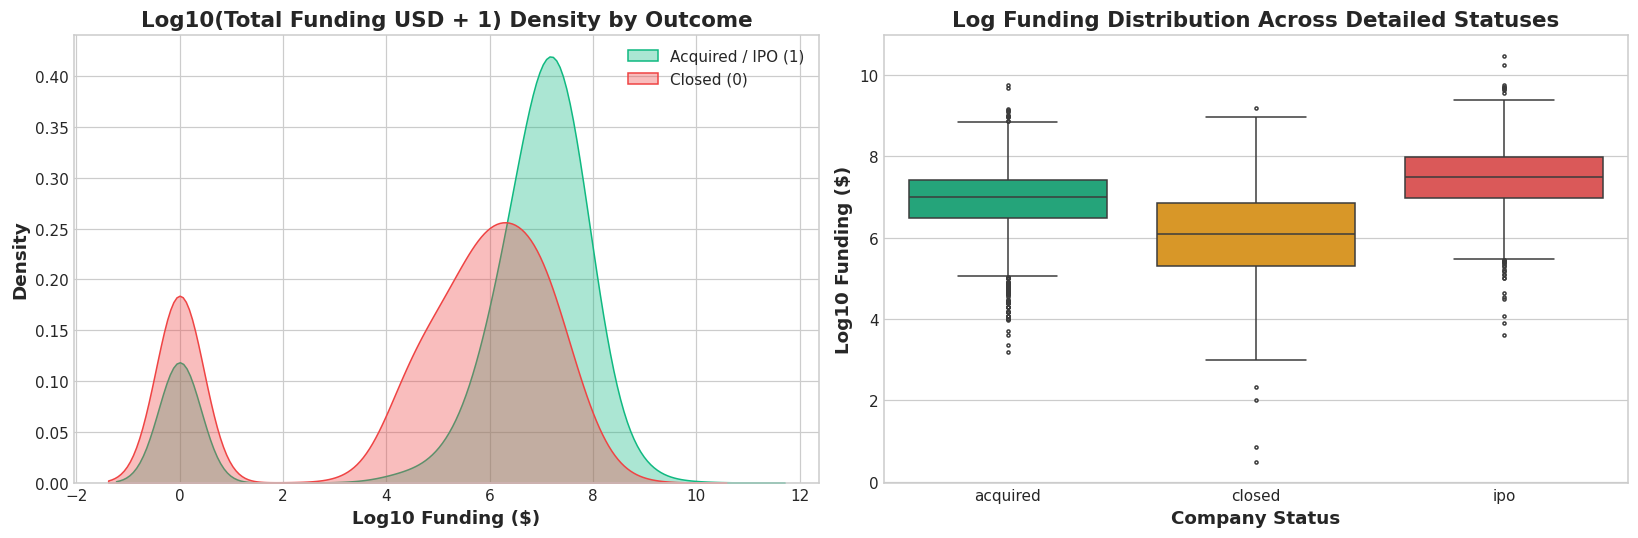

In [6]:
def clean_funding_series(val):
    if pd.isna(val):
        return 0.0
    val_str = str(val).strip().replace(',', '').replace('$', '')
    if val_str in ['-', '']:
        return 0.0
    try:
        return float(val_str)
    except:
        return 0.0

resolved_df['funding_total_usd_clean'] = resolved_df['funding_total_usd'].apply(clean_funding_series)
resolved_df['log_funding'] = np.log10(resolved_df['funding_total_usd_clean'] + 1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Subplot 1: Log Funding Distribution KDE by Outcome
sns.kdeplot(
    data=resolved_df[resolved_df['target'] == 1], 
    x='log_funding', 
    label='Acquired / IPO (1)', 
    color='#10B981', 
    fill=True, 
    alpha=0.35, 
    ax=axes[0]
)
sns.kdeplot(
    data=resolved_df[resolved_df['target'] == 0], 
    x='log_funding', 
    label='Closed (0)', 
    color='#EF4444', 
    fill=True, 
    alpha=0.35, 
    ax=axes[0]
)
axes[0].set_title('Log10(Total Funding USD + 1) Density by Outcome')
axes[0].set_xlabel('Log10 Funding ($)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Subplot 2: Funding Boxplot by Detailed Status
funded_df = resolved_df[resolved_df['funding_total_usd_clean'] > 0]
sns.boxplot(
    data=funded_df, 
    x='status', 
    y='log_funding', 
    palette=['#10B981', '#F59E0B', '#EF4444'], 
    ax=axes[1],
    fliersize=2
)
axes[1].set_title('Log Funding Distribution Across Detailed Statuses')
axes[1].set_xlabel('Company Status')
axes[1].set_ylabel('Log10 Funding ($)')

plt.tight_layout()
plt.show()


### Visualization 4: Funding Rounds Progression & Exit Rates


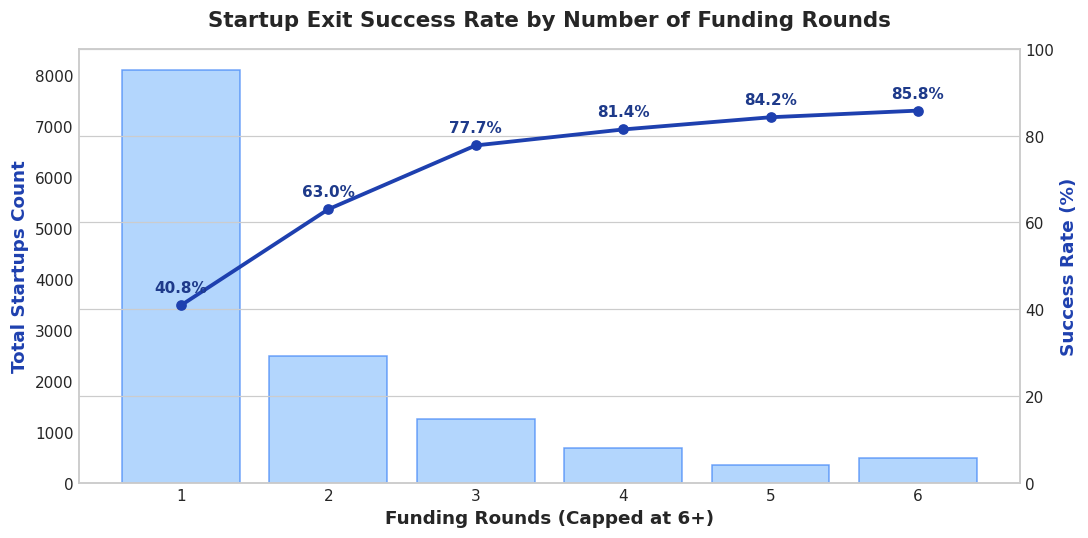

In [7]:
resolved_df['funding_rounds_clean'] = pd.to_numeric(resolved_df['funding_rounds'], errors='coerce').fillna(1)
resolved_df['rounds_capped'] = resolved_df['funding_rounds_clean'].clip(upper=6).astype(int)

round_stats = resolved_df.groupby('rounds_capped').agg(
    total=('target', 'count'),
    exits=('target', 'sum'),
    success_rate=('target', 'mean')
).reset_index()

fig, ax1 = plt.subplots(figsize=(10, 5))

ax2 = ax1.twinx()
bars = ax1.bar(
    round_stats['rounds_capped'].astype(str), 
    round_stats['total'], 
    color='#93C5FD', 
    alpha=0.7, 
    edgecolor='#3B82F6', 
    label='Total Startups'
)
line = ax2.plot(
    round_stats['rounds_capped'].astype(str), 
    round_stats['success_rate'] * 100, 
    color='#1E40AF', 
    marker='o', 
    linewidth=2.5, 
    label='Success Rate (%)'
)

ax1.set_title('Startup Exit Success Rate by Number of Funding Rounds', pad=15)
ax1.set_xlabel('Funding Rounds (Capped at 6+)')
ax1.set_ylabel('Total Startups Count', color='#1E40AF')
ax2.set_ylabel('Success Rate (%)', color='#1E40AF')
ax2.set_ylim(0, 100)
ax1.grid(False)

for i, rate in enumerate(round_stats['success_rate']):
    ax2.annotate(f"{rate*100:.1f}%", 
                 (i, rate*100 + 3), 
                 ha='center', fontweight='bold', color='#1E3A8A')

plt.tight_layout()
plt.show()


### Visualization 5: Temporal Lifecycle & Velocity KDE Analysis


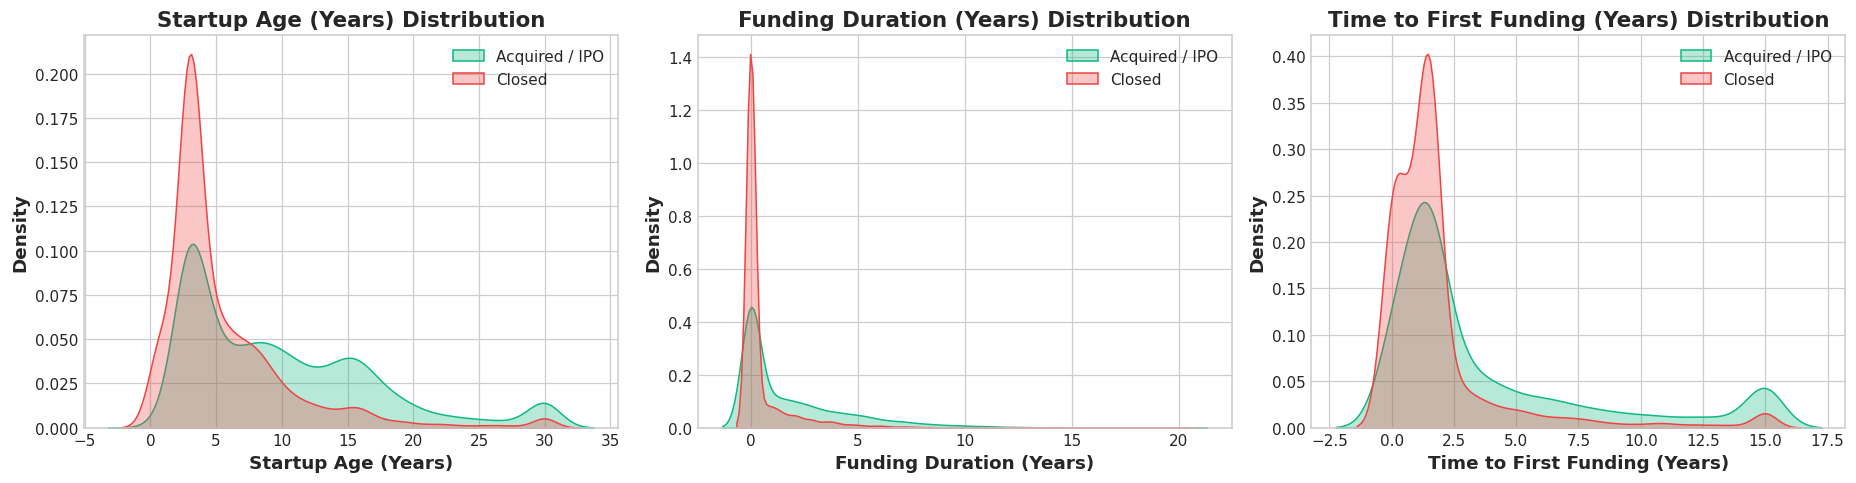

In [8]:
# Datetime parsing & temporal feature creation
resolved_df['founded_dt'] = pd.to_datetime(resolved_df['founded_at'], errors='coerce')
resolved_df['first_funding_dt'] = pd.to_datetime(resolved_df['first_funding_at'], errors='coerce')
resolved_df['last_funding_dt'] = pd.to_datetime(resolved_df['last_funding_at'], errors='coerce')

ref_year = 2015.0
resolved_df['startup_age_years'] = resolved_df['founded_dt'].apply(
    lambda d: max(0.5, min(ref_year - d.year, 30.0)) if pd.notnull(d) else 3.0
)
resolved_df['funding_duration_years'] = (
    (resolved_df['last_funding_dt'] - resolved_df['first_funding_dt']).dt.days / 365.25
).fillna(0.0).clip(lower=0.0, upper=20.0)

resolved_df['time_to_first_funding_years'] = (
    (resolved_df['first_funding_dt'] - resolved_df['founded_dt']).dt.days / 365.25
).fillna(1.5).clip(lower=0.0, upper=15.0)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

features_to_plot = [
    ('startup_age_years', 'Startup Age (Years)', axes[0]),
    ('funding_duration_years', 'Funding Duration (Years)', axes[1]),
    ('time_to_first_funding_years', 'Time to First Funding (Years)', axes[2])
]

for col, label, ax in features_to_plot:
    sns.kdeplot(data=resolved_df[resolved_df['target'] == 1], x=col, label='Acquired / IPO', color='#10B981', fill=True, alpha=0.3, ax=ax)
    sns.kdeplot(data=resolved_df[resolved_df['target'] == 0], x=col, label='Closed', color='#EF4444', fill=True, alpha=0.3, ax=ax)
    ax.set_title(f'{label} Distribution')
    ax.set_xlabel(label)
    ax.set_ylabel('Density')
    ax.legend()

plt.tight_layout()
plt.show()


### Visualization 6: Top Industry Sectors & Sector Success Rates


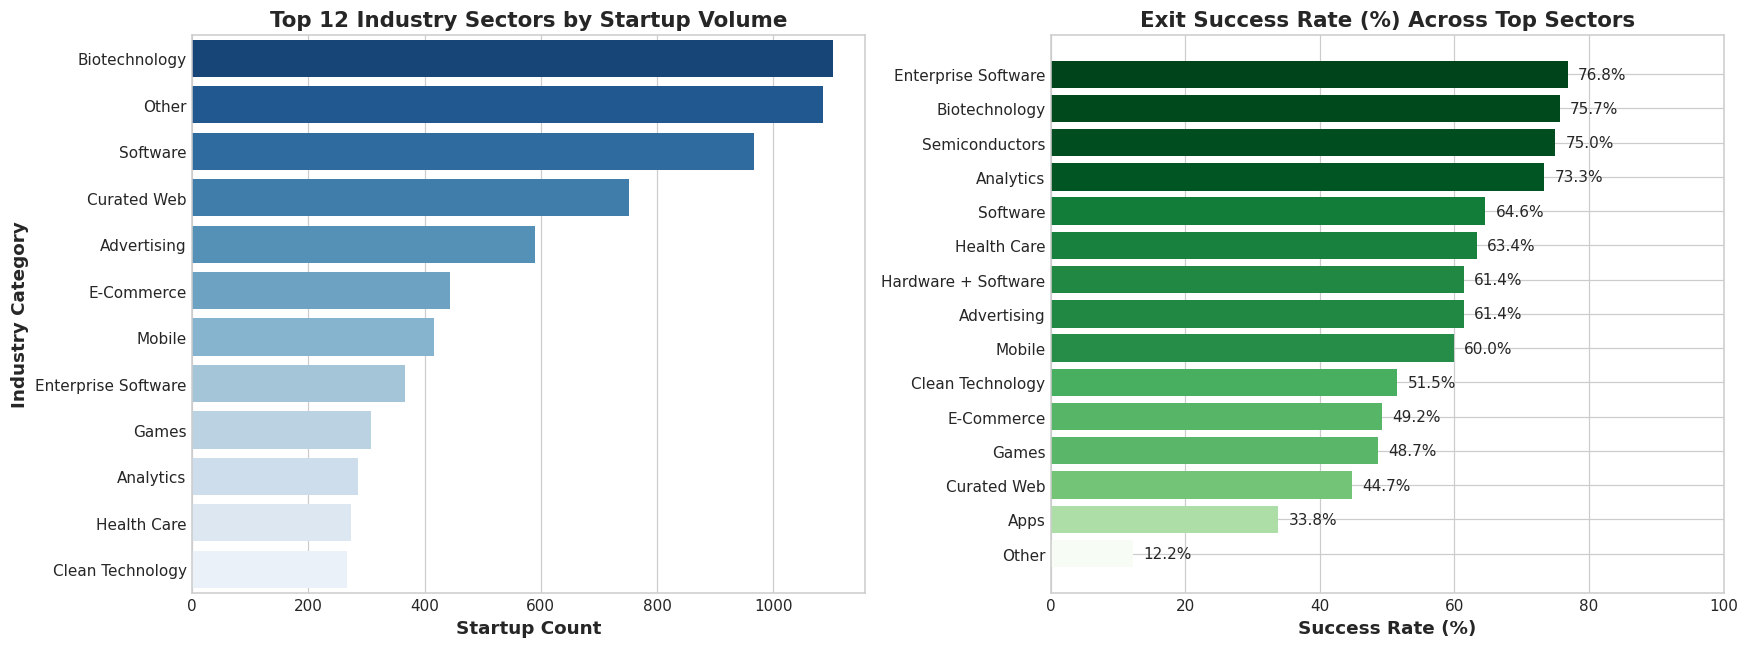

In [9]:
def extract_primary_category(cat):
    if pd.isna(cat) or str(cat).strip() == '':
        return 'Other'
    cats = [c.strip() for c in str(cat).split('|') if c.strip()]
    return cats[0] if cats else 'Other'

resolved_df['primary_category'] = resolved_df['category_list'].apply(extract_primary_category)
top_15_cats = resolved_df['primary_category'].value_counts().head(15).index.tolist()

cat_stats = resolved_df[resolved_df['primary_category'].isin(top_15_cats)].groupby('primary_category').agg(
    total=('target', 'count'),
    success_rate=('target', 'mean')
).sort_values('success_rate', ascending=True).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Total Volume by Sector
sns.barplot(
    data=resolved_df['primary_category'].value_counts().head(12).reset_index(),
    x='count',
    y='primary_category',
    palette='Blues_r',
    ax=axes[0]
)
axes[0].set_title('Top 12 Industry Sectors by Startup Volume')
axes[0].set_xlabel('Startup Count')
axes[0].set_ylabel('Industry Category')

# Subplot 2: Success Rate (%) by Sector
norm = plt.Normalize(cat_stats['success_rate'].min(), cat_stats['success_rate'].max())
colors = plt.cm.Greens(norm(cat_stats['success_rate'].values))

axes[1].barh(cat_stats['primary_category'], cat_stats['success_rate'] * 100, color=colors, edgecolor='none')
axes[1].set_title('Exit Success Rate (%) Across Top Sectors')
axes[1].set_xlabel('Success Rate (%)')
axes[1].set_xlim(0, 100)

for p in axes[1].patches:
    width = p.get_width()
    axes[1].annotate(f"{width:.1f}%", 
                     (width + 1.5, p.get_y() + p.get_height()/2),
                     ha='left', va='center', fontsize=10, fontweight='medium')

plt.tight_layout()
plt.show()


### Visualization 7: Geographic Ecosystem & Country-Level Exit Rate


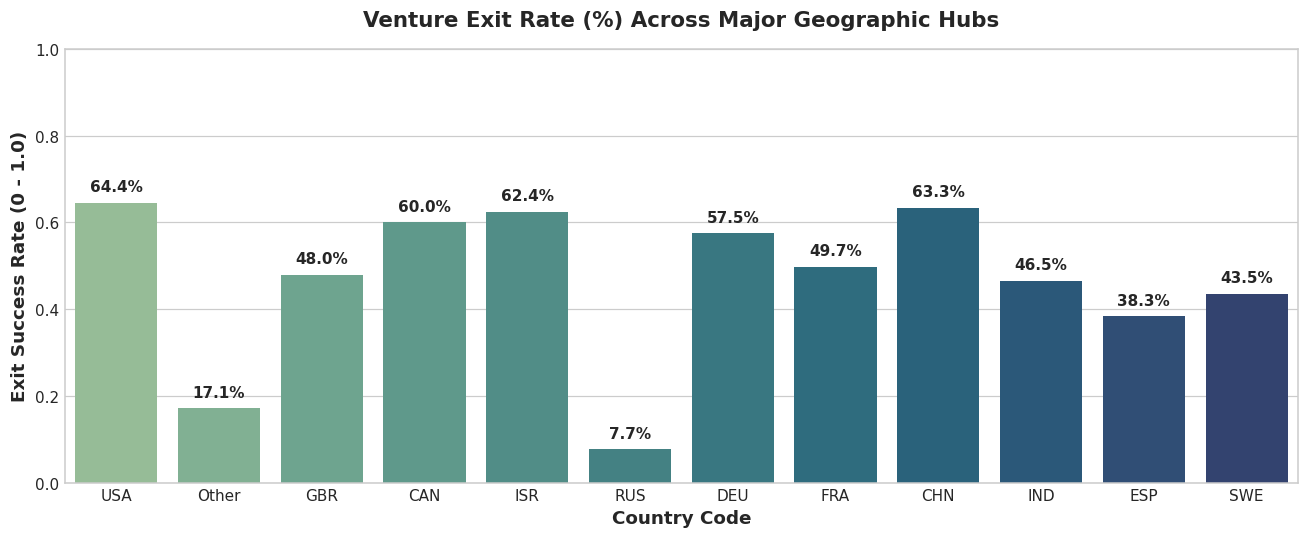

In [10]:
resolved_df['country_clean'] = resolved_df['country_code'].fillna('Other')
top_12_countries = resolved_df['country_clean'].value_counts().head(12).index.tolist()

country_stats = resolved_df[resolved_df['country_clean'].isin(top_12_countries)].groupby('country_clean').agg(
    total=('target', 'count'),
    success_rate=('target', 'mean')
).sort_values('total', ascending=False).reset_index()

plt.figure(figsize=(12, 5))
ax = sns.barplot(
    data=country_stats,
    x='country_clean',
    y='success_rate',
    palette='crest'
)
plt.title('Venture Exit Rate (%) Across Major Geographic Hubs', pad=15)
plt.xlabel('Country Code')
plt.ylabel('Exit Success Rate (0 - 1.0)')
plt.ylim(0, 1.0)

for p in ax.patches:
    h = p.get_height()
    ax.annotate(f"{h*100:.1f}%", 
                (p.get_x() + p.get_width()/2, h + 0.02),
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


### Visualization 8: Correlation Matrix Heatmap


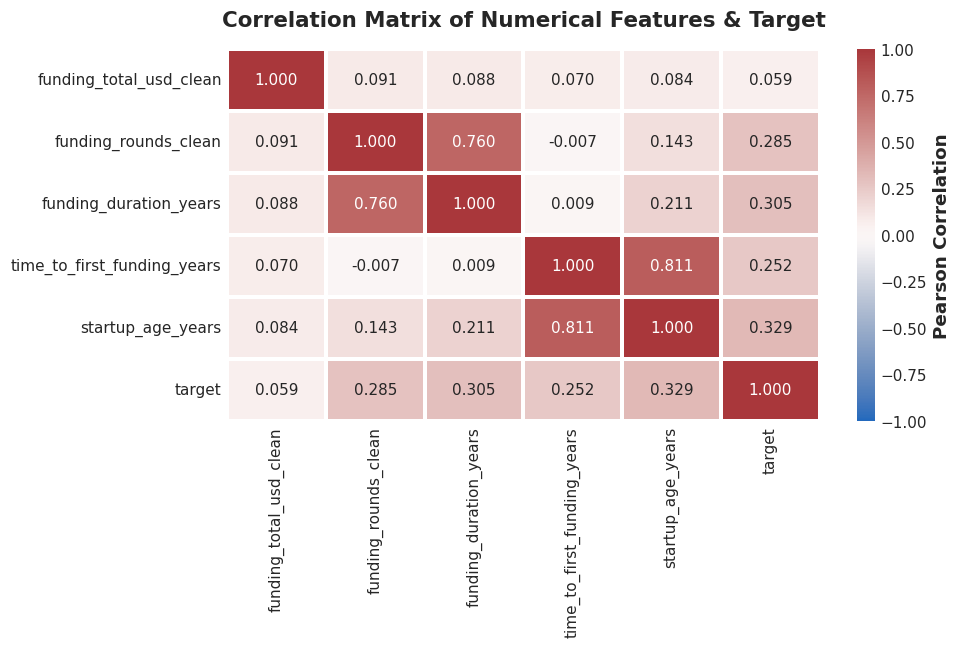

In [11]:
num_cols_for_corr = [
    'funding_total_usd_clean',
    'funding_rounds_clean',
    'funding_duration_years',
    'time_to_first_funding_years',
    'startup_age_years',
    'target'
]

corr_matrix = resolved_df[num_cols_for_corr].corr()

plt.figure(figsize=(9, 6))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".3f", 
    cmap='vlag', 
    vmin=-1, 
    vmax=1, 
    linewidths=1.5, 
    cbar_kws={'label': 'Pearson Correlation'}
)
plt.title('Correlation Matrix of Numerical Features & Target', pad=15)
plt.tight_layout()
plt.show()


### 5. Machine Learning Pipeline & Data Preprocessing


In [12]:
# Final category and country cleans
top_25_categories = resolved_df['primary_category'].value_counts().head(25).index.tolist()
resolved_df['primary_category_clean'] = resolved_df['primary_category'].apply(
    lambda c: c if c in top_25_categories else 'Other'
)

top_20_countries = resolved_df['country_clean'].value_counts().head(20).index.tolist()
if 'Other' not in top_20_countries:
    top_20_countries.append('Other')
resolved_df['country_code_clean'] = resolved_df['country_clean'].apply(
    lambda c: c if c in top_20_countries else 'Other'
)

num_features = [
    'funding_total_usd_clean',
    'funding_rounds_clean',
    'funding_duration_years',
    'time_to_first_funding_years',
    'startup_age_years'
]
cat_features = ['primary_category_clean', 'country_code_clean']

X = resolved_df[num_features + cat_features]
y = resolved_df['target']

# Stratified 80/20 train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"X_train Shape: {X_train.shape} -> Processed: {X_train_processed.shape}")
print(f"X_test Shape:  {X_test.shape} -> Processed: {X_test_processed.shape}")


X_train Shape: (10667, 7) -> Processed: (10667, 50)
X_test Shape:  (2667, 7) -> Processed: (2667, 50)


### 6. Multi-Model Training & Cross-Validation Benchmarking


In [13]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=150, max_depth=12, min_samples_split=5, random_state=42, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=120, learning_rate=0.08, max_depth=5, random_state=42)
}

cv_results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    scores = cross_val_score(model, X_train_processed, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f"5-Fold CV ROC-AUC for {name}: Mean = {scores.mean():.4f} (± {scores.std():.4f})")


5-Fold CV ROC-AUC for Logistic Regression: Mean = 0.7898 (± 0.0044)


5-Fold CV ROC-AUC for Random Forest: Mean = 0.8122 (± 0.0038)


5-Fold CV ROC-AUC for Gradient Boosting: Mean = 0.8137 (± 0.0026)


### Visualization 9: Cross-Validation ROC-AUC Distribution


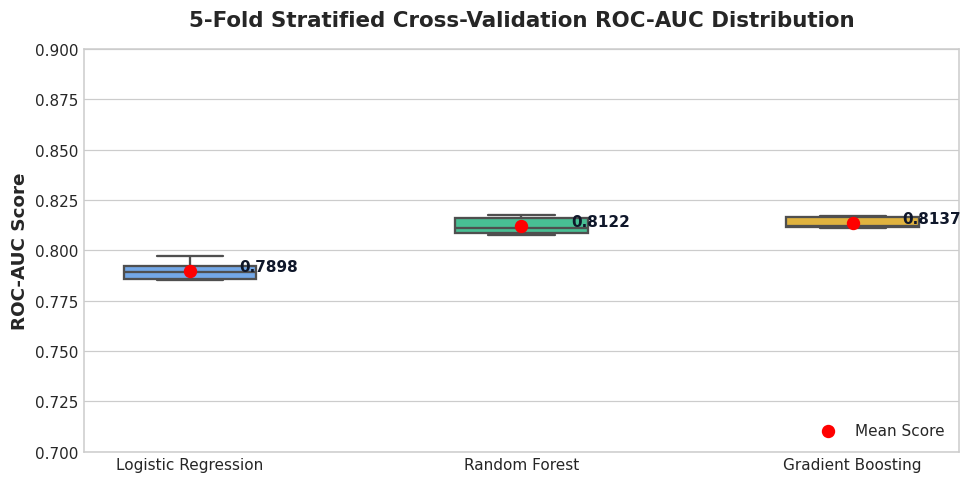

In [14]:
cv_df = pd.DataFrame(cv_results)

plt.figure(figsize=(9, 4.5))
sns.boxplot(data=cv_df, palette=['#60A5FA', '#34D399', '#FBBF24'], width=0.4, linewidth=1.5)
plt.title('5-Fold Stratified Cross-Validation ROC-AUC Distribution', pad=15)
plt.ylabel('ROC-AUC Score')
plt.ylim(0.70, 0.90)

for i, col in enumerate(cv_df.columns):
    mean_val = cv_df[col].mean()
    plt.scatter(i, mean_val, color='red', s=60, zorder=5, label='Mean Score' if i == 0 else "")
    plt.annotate(f"{mean_val:.4f}", (i + 0.15, mean_val), fontweight='bold', color='#0f172a')

plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


### 7. Model Evaluation & Benchmark Comparison


In [15]:
results = []
trained_models = {}
test_predictions = {}
test_probabilities = {}

for name, model in models.items():
    model.fit(X_train_processed, y_train)
    trained_models[name] = model
    
    y_pred = model.predict(X_test_processed)
    y_proba = model.predict_proba(X_test_processed)[:, 1]
    
    test_predictions[name] = y_pred
    test_probabilities[name] = y_proba
    
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })

benchmark_df = pd.DataFrame(results).set_index('Model')
benchmark_df.round(4)


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.7360,0.7782,0.7047,0.7396,0.8108
Random Forest,0.7537,0.7757,0.7555,0.7654,0.8298
Gradient Boosting,0.7548,0.7515,0.8055,0.7776,0.8325


### Visualization 10: Model Comparison Benchmark Dashboard


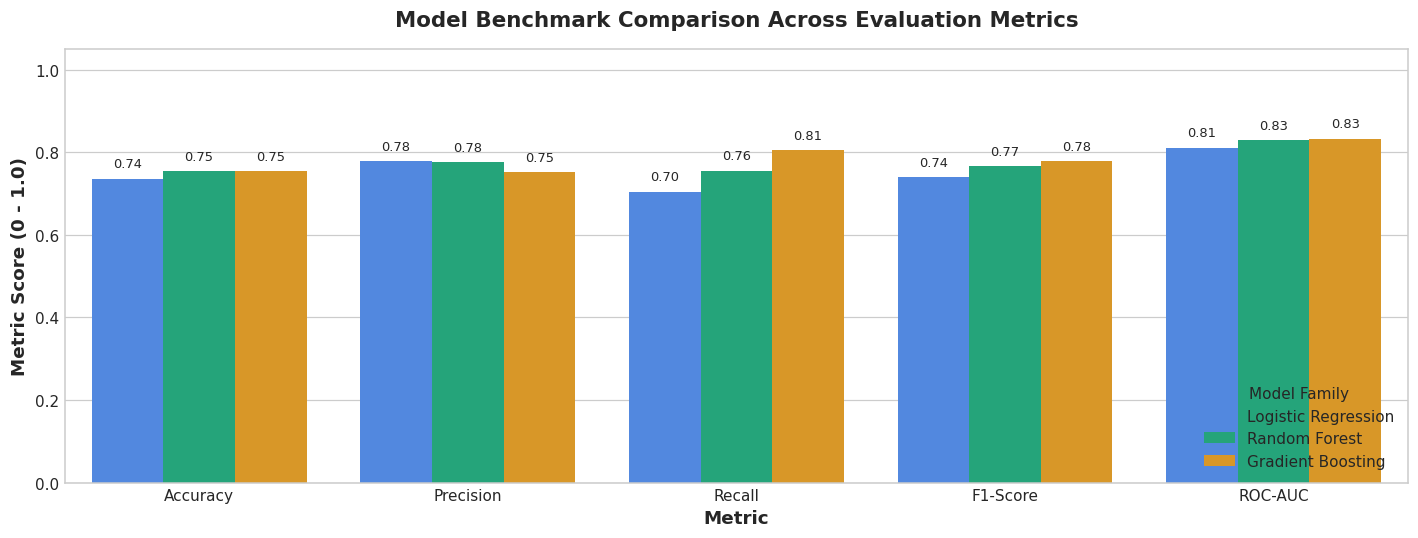

In [16]:
metrics_plot_df = benchmark_df.reset_index().melt(
    id_vars='Model', 
    var_name='Metric', 
    value_name='Score'
)

plt.figure(figsize=(13, 5))
ax = sns.barplot(
    data=metrics_plot_df, 
    x='Metric', 
    y='Score', 
    hue='Model', 
    palette=['#3B82F6', '#10B981', '#F59E0B']
)
plt.title('Model Benchmark Comparison Across Evaluation Metrics', pad=15)
plt.ylim(0, 1.05)
plt.ylabel('Metric Score (0 - 1.0)')
plt.legend(title='Model Family', loc='lower right')

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f"{height:.2f}", 
                    (p.get_x() + p.get_width() / 2, height + 0.02),
                    ha='center', va='bottom', fontsize=8.5, fontweight='medium')

plt.tight_layout()
plt.show()


### 8. Diagnostic Visualizations: ROC, PR Curves, Confusion Matrices


In [17]:
best_model_name = benchmark_df['ROC-AUC'].idxmax()
best_model = trained_models[best_model_name]
print(f"Selected Champion Model: {best_model_name} (ROC-AUC: {benchmark_df.loc[best_model_name, 'ROC-AUC']:.4f})")
print("\nClassification Report:\n")
print(classification_report(y_test, test_predictions[best_model_name], target_names=['Closed', 'Acquired/IPO']))


Selected Champion Model: Gradient Boosting (ROC-AUC: 0.8325)

Classification Report:

              precision    recall  f1-score   support

      Closed       0.76      0.70      0.73      1248
Acquired/IPO       0.75      0.81      0.78      1419

    accuracy                           0.75      2667
   macro avg       0.76      0.75      0.75      2667
weighted avg       0.76      0.75      0.75      2667



### Visualization 11: Confusion Matrix (Counts & Normalized)


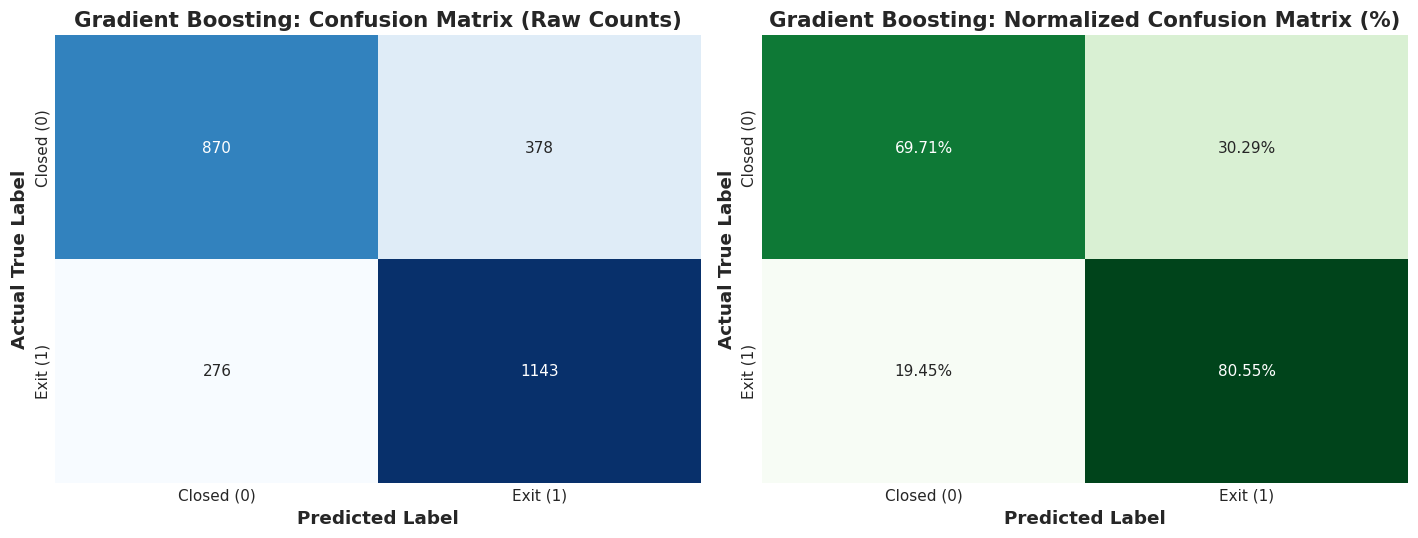

In [18]:
cm_counts = confusion_matrix(y_test, test_predictions[best_model_name])
cm_norm = confusion_matrix(y_test, test_predictions[best_model_name], normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Subplot 1: Absolute Counts
sns.heatmap(
    cm_counts, 
    annot=True, 
    fmt="d", 
    cmap='Blues', 
    cbar=False, 
    ax=axes[0],
    xticklabels=['Closed (0)', 'Exit (1)'],
    yticklabels=['Closed (0)', 'Exit (1)']
)
axes[0].set_title(f'{best_model_name}: Confusion Matrix (Raw Counts)')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('Actual True Label')

# Subplot 2: Normalized Percentages
sns.heatmap(
    cm_norm, 
    annot=True, 
    fmt=".2%", 
    cmap='Greens', 
    cbar=False, 
    ax=axes[1],
    xticklabels=['Closed (0)', 'Exit (1)'],
    yticklabels=['Closed (0)', 'Exit (1)']
)
axes[1].set_title(f'{best_model_name}: Normalized Confusion Matrix (%)')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('Actual True Label')

plt.tight_layout()
plt.show()


### Visualization 12 & 13: ROC-AUC and Precision-Recall Curves


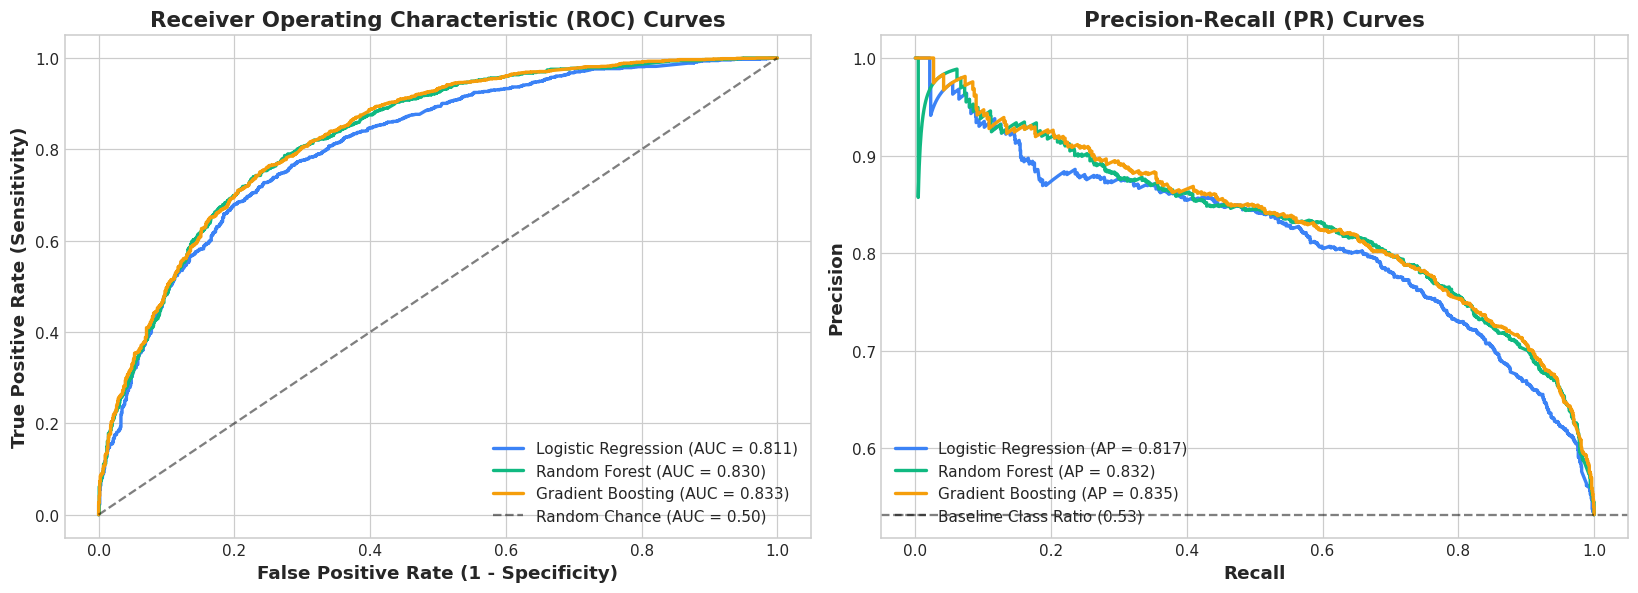

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Subplot 1: ROC Curves for all models
model_colors = {'Logistic Regression': '#3B82F6', 'Random Forest': '#10B981', 'Gradient Boosting': '#F59E0B'}

for name in models.keys():
    fpr, tpr, _ = roc_curve(y_test, test_probabilities[name])
    auc_val = roc_auc_score(y_test, test_probabilities[name])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC = {auc_val:.3f})", color=model_colors[name], linewidth=2.2)

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Chance (AUC = 0.50)')
axes[0].set_title('Receiver Operating Characteristic (ROC) Curves')
axes[0].set_xlabel('False Positive Rate (1 - Specificity)')
axes[0].set_ylabel('True Positive Rate (Sensitivity)')
axes[0].legend(loc='lower right')

# Subplot 2: Precision-Recall Curves
for name in models.keys():
    prec, rec, _ = precision_recall_curve(y_test, test_probabilities[name])
    ap_val = average_precision_score(y_test, test_probabilities[name])
    axes[1].plot(rec, prec, label=f"{name} (AP = {ap_val:.3f})", color=model_colors[name], linewidth=2.2)

baseline_pr = y_test.mean()
axes[1].axhline(y=baseline_pr, color='k', linestyle='--', alpha=0.5, label=f'Baseline Class Ratio ({baseline_pr:.2f})')
axes[1].set_title('Precision-Recall (PR) Curves')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(loc='lower left')

plt.tight_layout()
plt.show()


### Visualization 14: Top 18 Most Influential Feature Importances


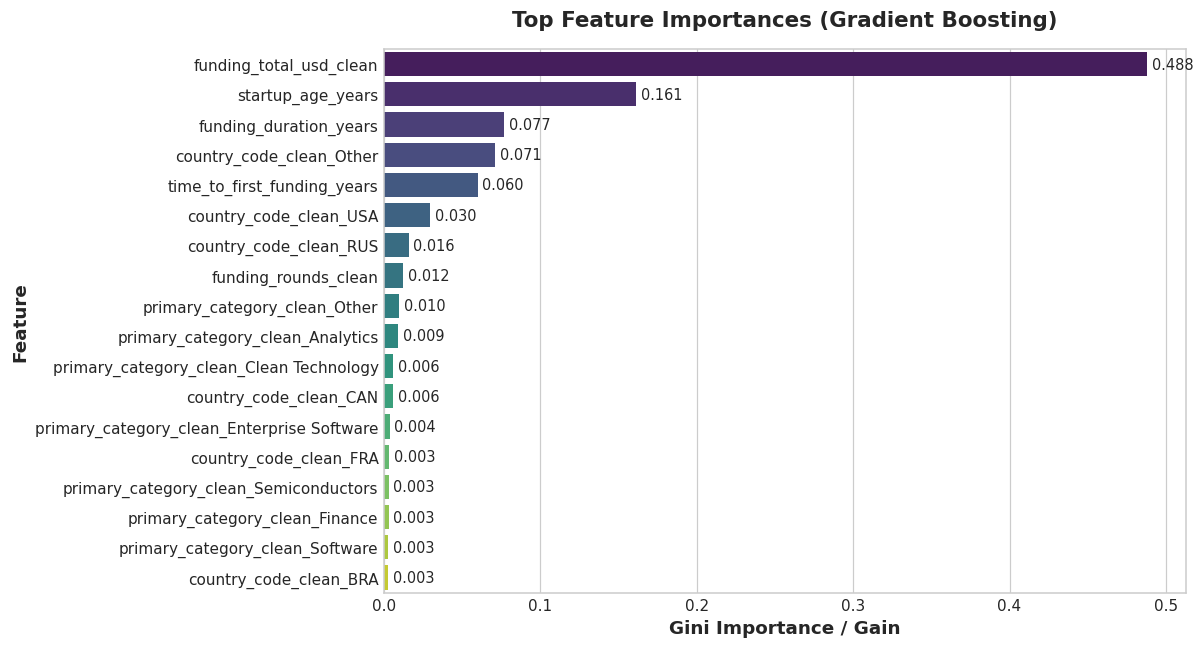

In [20]:
cat_encoder = preprocessor.named_transformers_['cat']
cat_feature_names = cat_encoder.get_feature_names_out(cat_features).tolist()
all_feature_names = num_features + cat_feature_names

if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    feat_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
    feat_df = feat_df.sort_values('Importance', ascending=False).head(18)
    
    plt.figure(figsize=(11, 6))
    ax = sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis')
    plt.title(f'Top Feature Importances ({best_model_name})', pad=15)
    plt.xlabel('Gini Importance / Gain')
    plt.ylabel('Feature')
    
    for p in ax.patches:
        val = p.get_width()
        ax.annotate(f"{val:.3f}", 
                    (val + 0.003, p.get_y() + p.get_height()/2),
                    ha='left', va='center', fontsize=9.5)
                    
    plt.tight_layout()
    plt.show()


### Visualization 15: Predicted Probability Calibration Density


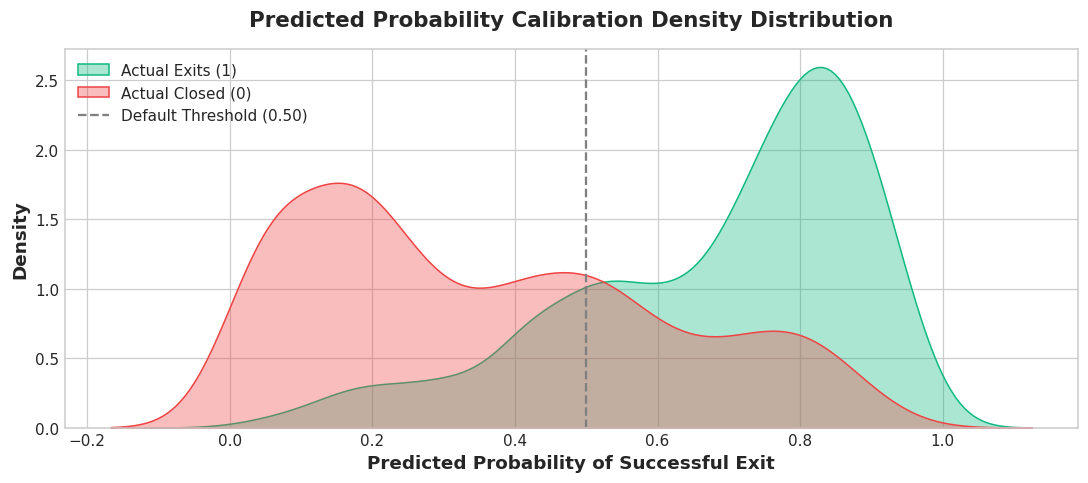

In [21]:
best_probas = test_probabilities[best_model_name]
eval_df = pd.DataFrame({'True_Status': y_test.values, 'Predicted_Probability': best_probas})

plt.figure(figsize=(10, 4.5))
sns.kdeplot(data=eval_df[eval_df['True_Status'] == 1], x='Predicted_Probability', label='Actual Exits (1)', color='#10B981', fill=True, alpha=0.35)
sns.kdeplot(data=eval_df[eval_df['True_Status'] == 0], x='Predicted_Probability', label='Actual Closed (0)', color='#EF4444', fill=True, alpha=0.35)

plt.axvline(0.5, color='gray', linestyle='--', linewidth=1.5, label='Default Threshold (0.50)')
plt.title('Predicted Probability Calibration Density Distribution', pad=15)
plt.xlabel('Predicted Probability of Successful Exit')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()


### 9. Decision Threshold Optimization for Venture Capital


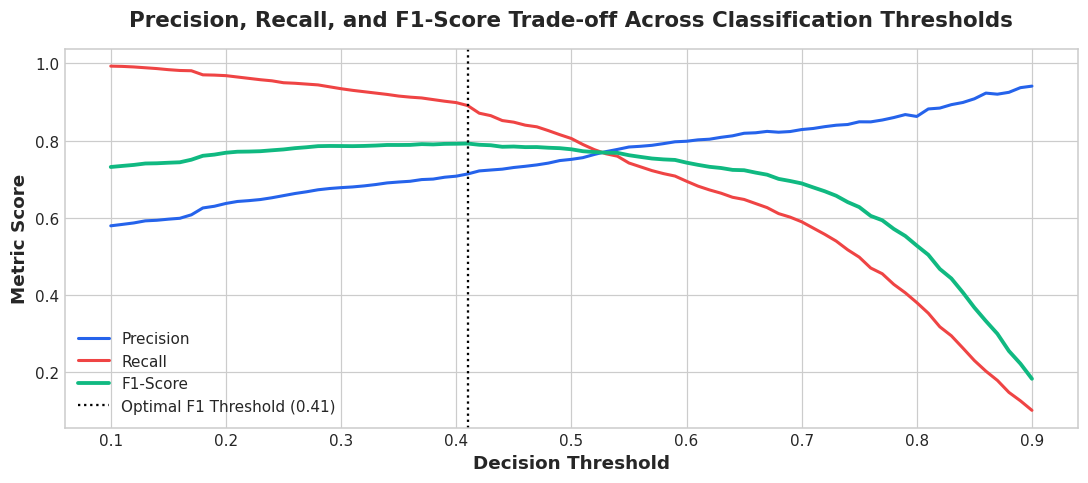

Maximum F1-Score of 0.7925 achieved at Threshold = 0.41


In [22]:
thresholds = np.linspace(0.1, 0.9, 81)
threshold_metrics = []

for t in thresholds:
    preds = (best_probas >= t).astype(int)
    threshold_metrics.append({
        'Threshold': t,
        'Precision': precision_score(y_test, preds, zero_division=0),
        'Recall': recall_score(y_test, preds, zero_division=0),
        'F1_Score': f1_score(y_test, preds, zero_division=0)
    })

t_df = pd.DataFrame(threshold_metrics)

plt.figure(figsize=(10, 4.5))
plt.plot(t_df['Threshold'], t_df['Precision'], label='Precision', color='#2563EB', linewidth=2)
plt.plot(t_df['Threshold'], t_df['Recall'], label='Recall', color='#EF4444', linewidth=2)
plt.plot(t_df['Threshold'], t_df['F1_Score'], label='F1-Score', color='#10B981', linewidth=2.5)

opt_t = t_df.loc[t_df['F1_Score'].idxmax(), 'Threshold']
plt.axvline(opt_t, color='black', linestyle=':', label=f'Optimal F1 Threshold ({opt_t:.2f})')

plt.title('Precision, Recall, and F1-Score Trade-off Across Classification Thresholds', pad=15)
plt.xlabel('Decision Threshold')
plt.ylabel('Metric Score')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Maximum F1-Score of {t_df['F1_Score'].max():.4f} achieved at Threshold = {opt_t:.2f}")


### 10. Model Artifact Serialization & Metadata Generation


In [23]:
output_dir = 'ml_pipelines' if os.path.exists('ml_pipelines') else '.'
os.makedirs(output_dir, exist_ok=True)

model_file = os.path.join(output_dir, 'model.pkl')
preprocessor_file = os.path.join(output_dir, 'preprocessor.pkl')
metadata_file = os.path.join(output_dir, 'metadata.json')

joblib.dump(best_model, model_file)
joblib.dump(preprocessor, preprocessor_file)

# Build feature importance list
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    feat_importance_list = sorted(
        [{'feature': name, 'importance': round(float(imp), 4)} for name, imp in zip(all_feature_names, importances)],
        key=lambda x: x['importance'],
        reverse=True
    )[:15]
else:
    feat_importance_list = []

# Top category and country success statistics
category_stats = {}
for cat in top_25_categories:
    sub = resolved_df[resolved_df['primary_category'] == cat]
    total = len(sub)
    success_cnt = int((sub['target'] == 1).sum())
    category_stats[cat] = {
        'total': total,
        'success_rate': round(success_cnt / total if total > 0 else 0, 3),
        'avg_funding': round(float(sub['funding_total_usd_clean'].mean()), 2)
    }

country_stats = {}
for c in top_20_countries:
    sub = resolved_df[resolved_df['country_code_clean'] == c]
    total = len(sub)
    success_cnt = int((sub['target'] == 1).sum())
    country_stats[c] = {
        'total': total,
        'success_rate': round(success_cnt / total if total > 0 else 0, 3)
    }

metadata = {
    "best_model": best_model_name,
    "models_comparison": benchmark_df.to_dict(orient='index'),
    "metrics": benchmark_df.loc[best_model_name].to_dict(),
    "top_features": feat_importance_list,
    "num_features": num_features,
    "cat_features": cat_features,
    "top_categories": top_25_categories,
    "top_countries": top_20_countries,
    "category_stats": category_stats,
    "country_stats": country_stats,
    "optimal_threshold": round(float(opt_t), 2),
    "dataset_summary": {
        "total_rows": int(len(raw_df)),
        "resolved_rows": int(len(resolved_df)),
        "operating_count": int((raw_df['status'] == 'operating').sum()),
        "acquired_count": int((raw_df['status'] == 'acquired').sum()),
        "closed_count": int((raw_df['status'] == 'closed').sum()),
        "ipo_count": int((raw_df['status'] == 'ipo').sum())
    }
}

with open(metadata_file, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"Successfully saved:")
print(f"  -> Model: {model_file} ({os.path.getsize(model_file)/1024:.1f} KB)")
print(f"  -> Preprocessor: {preprocessor_file} ({os.path.getsize(preprocessor_file)/1024:.1f} KB)")
print(f"  -> Metadata: {metadata_file} ({os.path.getsize(metadata_file)/1024:.1f} KB)")


Successfully saved:
  -> Model: ml_pipelines\model.pkl (668.2 KB)
  -> Preprocessor: ml_pipelines\preprocessor.pkl (4.1 KB)
  -> Metadata: ml_pipelines\metadata.json (7.8 KB)


### 11. Interactive Inference Simulation & Strategic Advisory


In [24]:
# Load back exported artifacts
loaded_model = joblib.load(model_file)
loaded_preprocessor = joblib.load(preprocessor_file)

test_startups = pd.DataFrame([
    {
        'Company_Name': 'Synapse AI Labs',
        'funding_total_usd_clean': 18500000.0,
        'funding_rounds_clean': 3,
        'funding_duration_years': 2.8,
        'time_to_first_funding_years': 0.8,
        'startup_age_years': 4.0,
        'primary_category_clean': 'Software',
        'country_code_clean': 'USA'
    },
    {
        'Company_Name': 'BioVanguard Therapeutics',
        'funding_total_usd_clean': 35000000.0,
        'funding_rounds_clean': 4,
        'funding_duration_years': 4.5,
        'time_to_first_funding_years': 1.2,
        'startup_age_years': 6.0,
        'primary_category_clean': 'Biotechnology',
        'country_code_clean': 'GBR'
    },
    {
        'Company_Name': 'LocalEats Quick Delivery',
        'funding_total_usd_clean': 150000.0,
        'funding_rounds_clean': 1,
        'funding_duration_years': 0.0,
        'time_to_first_funding_years': 2.5,
        'startup_age_years': 2.0,
        'primary_category_clean': 'E-Commerce',
        'country_code_clean': 'IND'
    }
])

inference_features = num_features + cat_features
X_sim = loaded_preprocessor.transform(test_startups[inference_features])
probabilities = loaded_model.predict_proba(X_sim)[:, 1]

test_startups['Success_Probability'] = [f"{p*100:.1f}%" for p in probabilities]
test_startups['Risk_Tier'] = [
    '🟢 High Potential Exit' if p >= 0.70 else ('🟡 Moderate / Watchlist' if p >= 0.40 else '🔴 High Risk')
    for p in probabilities
]

test_startups[['Company_Name', 'primary_category_clean', 'country_code_clean', 'funding_total_usd_clean', 'funding_rounds_clean', 'Success_Probability', 'Risk_Tier']]


,Company_Name,primary_category_clean,country_code_clean,funding_total_usd_clean,funding_rounds_clean,Success_Probability,Risk_Tier
0,Synapse AI Labs,Software,USA,18500000.0,3,83.1%,🟢 High Potential Exit
1,BioVanguard Therapeutics,Biotechnology,GBR,35000000.0,4,84.7%,🟢 High Potential Exit
2,LocalEats Quick Delivery,E-Commerce,IND,150000.0,1,18.1%,🔴 High Risk


### 12. Strategic Conclusions & Venture Insights
